# 🍎 Fruits & Vegetables AI – Block 2: ML Model (Calorie Prediction)

## Objective
Train and compare regression models to predict the **calorie content per 100g** of a food item
based on its macronutrients (protein, fat, carbs, fiber).

## Integration with other blocks
- **Input from CV block:** food category (fruit/vegetable type detected by CLIP)
- **Output to NLP block:** predicted calories + nutritional profile → used to generate recipe advice

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/nutrition_clean.csv')
df = df.dropna()
print(f'Shape: {df.shape}')
df.head()

Shape: (329, 11)


,Food,Category,Grams,Calories,calories_per_100g,protein_per_100g,fat_per_100g,carbs_per_100g,fiber_per_100g,satfat_per_100g,category_encoded
0,Cows' milk,Dairy products,976,660.0,67.62,3.28,4.10,4.92,0.0,3.69,1
1,Milk skim,Dairy products,984,360.0,36.59,3.66,0.00,5.28,0.0,0.00,1
2,Buttermilk,Dairy products,246,127.0,51.63,3.66,2.03,5.28,0.0,1.63,1
3,"Evaporated, undiluted",Dairy products,252,345.0,136.90,6.35,7.94,9.52,0.0,7.14,1
4,Fortified milk,Dairy products,1419,1373.0,96.76,6.27,2.96,8.39,0.1,1.62,1


## 1. Feature Selection

In [7]:
FEATURES = ['protein_per_100g', 'fat_per_100g', 'carbs_per_100g', 'fiber_per_100g', 'category_encoded']
TARGET = 'calories_per_100g'

X = df[FEATURES]
y = df[TARGET]

print(f'Features: {FEATURES}')
print(f'Target: {TARGET}')
print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'\nTarget stats:\n{y.describe()}')

Features: ['protein_per_100g', 'fat_per_100g', 'carbs_per_100g', 'fiber_per_100g', 'category_encoded']
Target: calories_per_100g
X shape: (329, 5), y shape: (329,)

Target stats:
count    329.000000
mean     203.682614
std      188.506624
min        0.000000
25%       51.630000
50%      140.910000
75%      305.080000
max      901.820000
Name: calories_per_100g, dtype: float64


## 2. Train/Test Split & Preprocessing

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (263, 5), Test: (66, 5)


## 3. Model Training & Comparison (Iteration 1: Baseline)

In [9]:
models_iter1 = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models_iter1.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results.append({
        'Model': name, 'Iteration': 1,
        'CV R² Mean': round(cv_scores.mean(), 4),
        'CV R² Std':  round(cv_scores.std(),  4),
        'Test R²': round(r2, 4), 'RMSE': round(rmse, 2), 'MAE': round(mae, 2)
    })
    print(f'{name}: CV R²={cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test R²={r2:.4f} | RMSE={rmse:.2f}')

Linear Regression: CV R²=0.8842 ± 0.1347 | Test R²=0.9501 | RMSE=41.99
Random Forest: CV R²=0.9127 ± 0.0598 | Test R²=0.9408 | RMSE=45.76


## 4. Model Training & Comparison (Iteration 2: Improved)

In [10]:
X_train2 = X_train.copy()
X_test2  = X_test.copy()
X_train2['fat_x_carbs'] = X_train2['fat_per_100g'] * X_train2['carbs_per_100g']
X_test2['fat_x_carbs']  = X_test2['fat_per_100g']  * X_test2['carbs_per_100g']

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled  = scaler2.transform(X_test2)

models_iter2 = {
    'Ridge (alpha=1.0)':    Ridge(alpha=1.0),
    'Tuned Random Forest':  RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_split=2, random_state=42
    )
}

best_model  = None
best_r2     = -999
best_scaler = None

for name, model in models_iter2.items():
    cv_scores = cross_val_score(model, X_train2_scaled, y_train, cv=kf, scoring='r2')
    model.fit(X_train2_scaled, y_train)
    y_pred = model.predict(X_test2_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results.append({
        'Model': name, 'Iteration': 2,
        'CV R² Mean': round(cv_scores.mean(), 4),
        'CV R² Std':  round(cv_scores.std(),  4),
        'Test R²': round(r2, 4), 'RMSE': round(rmse, 2), 'MAE': round(mae, 2)
    })
    print(f'{name}: CV R²={cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test R²={r2:.4f} | RMSE={rmse:.2f}')

    if r2 > best_r2:
        best_r2     = r2
        best_model  = model
        best_scaler = scaler2

print(f'\n✅ Best model: {type(best_model).__name__} with R²={best_r2:.4f}')

Ridge (alpha=1.0): CV R²=0.8975 ± 0.1075 | Test R²=0.9393 | RMSE=46.31
Tuned Random Forest: CV R²=0.9152 ± 0.0548 | Test R²=0.9439 | RMSE=44.52

✅ Best model: RandomForestRegressor with R²=0.9439


## 5. Results Summary

In [11]:
results_df = pd.DataFrame(results)
print('=== Model Comparison ===')
print(results_df.to_string(index=False))

=== Model Comparison ===
              Model  Iteration  CV R² Mean  CV R² Std  Test R²  RMSE   MAE
  Linear Regression          1      0.8842     0.1347   0.9501 41.99 25.22
      Random Forest          1      0.9127     0.0598   0.9408 45.76 25.73
  Ridge (alpha=1.0)          2      0.8975     0.1075   0.9393 46.31 26.07
Tuned Random Forest          2      0.9152     0.0548   0.9439 44.52 24.32


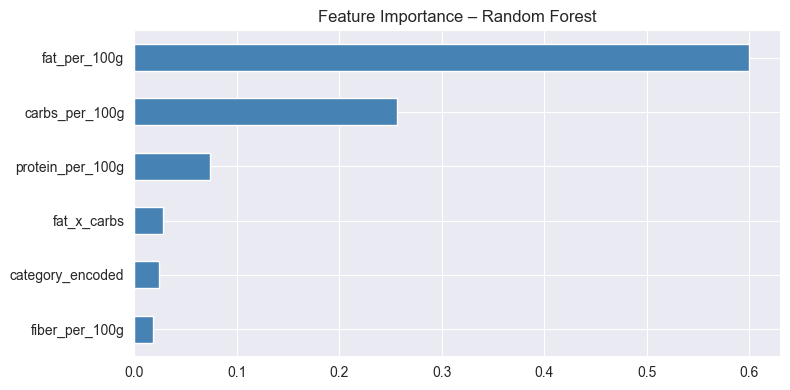

In [12]:
rf_model      = models_iter2['Tuned Random Forest']
feature_names = list(X_train2.columns)
importances   = rf_model.feature_importances_

fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(importances, index=feature_names).sort_values().plot(
    kind='barh', ax=ax, color='steelblue'
)
ax.set_title('Feature Importance – Random Forest')
plt.tight_layout()
plt.savefig('../data/ml_feature_importance.png', dpi=100)
plt.show()

In [13]:
joblib.dump(best_model,   '../data/best_model.pkl')
joblib.dump(best_scaler,  '../data/scaler.pkl')
joblib.dump(feature_names,'../data/feature_names.pkl')
print('✅ Model saved to data/best_model.pkl')
print('✅ Scaler saved to data/scaler.pkl')

✅ Model saved to data/best_model.pkl
✅ Scaler saved to data/scaler.pkl


## 6. Prediction Function (used by App)

In [14]:
def predict_calories(protein, fat, carbs, fiber, category_code=0):
    """Predict calories per 100g given macronutrients.
    This function is called by the Gradio app after CV identifies the food type.
    """
    model  = joblib.load('../data/best_model.pkl')
    scaler = joblib.load('../data/scaler.pkl')
    fat_x_carbs    = fat * carbs
    features       = np.array([[protein, fat, carbs, fiber, category_code, fat_x_carbs]])
    features_scaled = scaler.transform(features)
    return round(model.predict(features_scaled)[0], 1)

print('Test prediction (apple-like: protein=0.3, fat=0.2, carbs=14, fiber=2.4):')
print(f'Predicted calories: {predict_calories(0.3, 0.2, 14, 2.4)} kcal/100g')
print('(Real apple: ~52 kcal/100g)')

Test prediction (apple-like: protein=0.3, fat=0.2, carbs=14, fiber=2.4):
Predicted calories: 58.7 kcal/100g
(Real apple: ~52 kcal/100g)


---
## 7. Error Analysis

This section fulfils the ML block requirement: **interpretation of results and error analysis**.
We analyse where the Ridge Regression model fails, which food items are hardest to predict, and why.

In [15]:
# ── Generate predictions on test set ─────────────────────────────────────────
y_pred_test = best_model.predict(best_scaler.transform(X_test2))
residuals   = y_test.values - y_pred_test

error_df = pd.DataFrame({
    'Food':      df.loc[X_test2.index, 'Food'],
    'Category':  df.loc[X_test2.index, 'Category'],
    'Actual':    y_test.values,
    'Predicted': y_pred_test.round(1),
    'Residual':  residuals.round(1),
    'Abs_Error': np.abs(residuals).round(1)
}).reset_index(drop=True)

print(f'Test set size: {len(error_df)} samples')
print(f'Mean Absolute Error (MAE):  {error_df["Abs_Error"].mean():.2f} kcal')
print(f'Median Absolute Error:      {error_df["Abs_Error"].median():.2f} kcal')
print(f'Max error:                  {error_df["Abs_Error"].max():.2f} kcal')
print(f'\nWorst 10 predictions:')
print(error_df.nlargest(10, 'Abs_Error')[['Food','Category','Actual','Predicted','Residual']].to_string(index=False))

Test set size: 66 samples
Mean Absolute Error (MAE):  24.32 kcal
Median Absolute Error:      10.25 kcal
Max error:                  246.60 kcal

Worst 10 predictions:
                                Food                  Category  Actual  Predicted  Residual
                                 Gin Drinks,Alcohol, Beverages  250.00        3.4     246.6
               Chicken livers, fried             Meat, Poultry  140.00      251.1    -111.1
                               Bacon             Meat, Poultry  593.75      487.4     106.4
                         Leg roasted             Meat, Poultry  365.12      287.3      77.8
                                Lard   Fats, Oils, Shortenings  901.82      830.9      70.9
      Brown, firm-packed, dark sugar             Jams, Jellies  370.45      299.8      70.7
                            Scallops             Fish, Seafood  104.00      174.0     -70.0
                                Ices          Desserts, sweets   78.00      146.9     -68.9
     

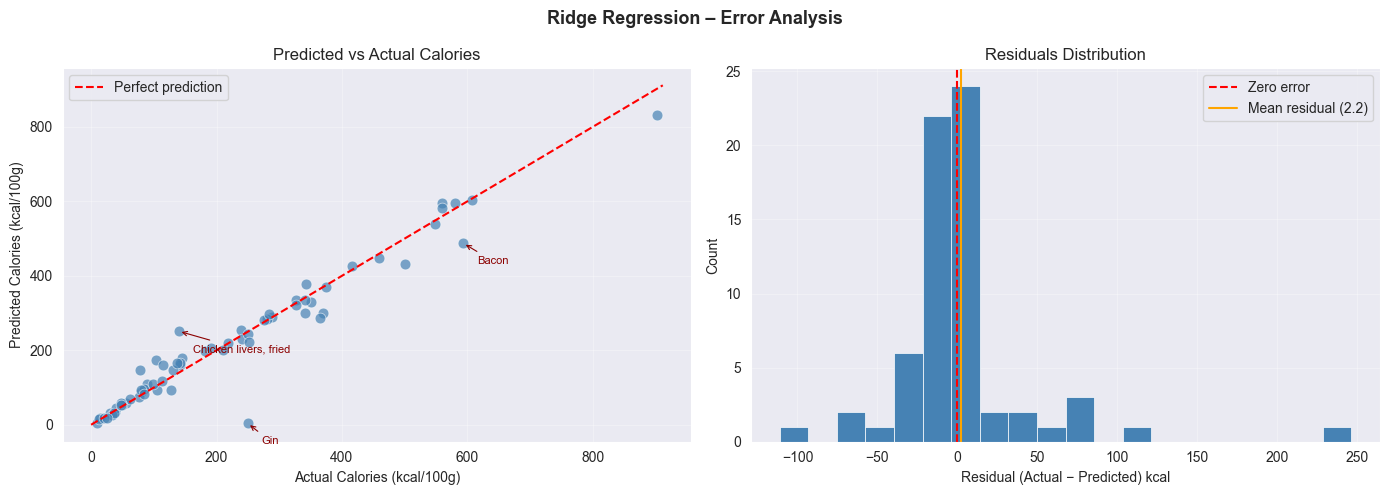

✅ Saved ml_error_analysis.png


In [16]:
# ── Plot 1: Predicted vs Actual + Residuals Distribution ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(error_df['Actual'], error_df['Predicted'],
           alpha=0.7, edgecolors='white', linewidth=0.5, color='steelblue', s=60)
lims = [error_df['Actual'].min() - 10, error_df['Actual'].max() + 10]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Calories (kcal/100g)')
ax.set_ylabel('Predicted Calories (kcal/100g)')
ax.set_title('Predicted vs Actual Calories')
ax.legend()
ax.grid(True, alpha=0.3)
for _, row in error_df.nlargest(3, 'Abs_Error').iterrows():
    ax.annotate(row['Food'],
                xy=(row['Actual'], row['Predicted']),
                xytext=(10, -15), textcoords='offset points',
                fontsize=8, color='darkred',
                arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))

ax = axes[1]
ax.hist(error_df['Residual'], bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
ax.axvline(x=error_df['Residual'].mean(), color='orange', linestyle='-',
           linewidth=1.5, label=f'Mean residual ({error_df["Residual"].mean():.1f})')
ax.set_xlabel('Residual (Actual − Predicted) kcal')
ax.set_ylabel('Count')
ax.set_title('Residuals Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Ridge Regression – Error Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/ml_error_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved ml_error_analysis.png')

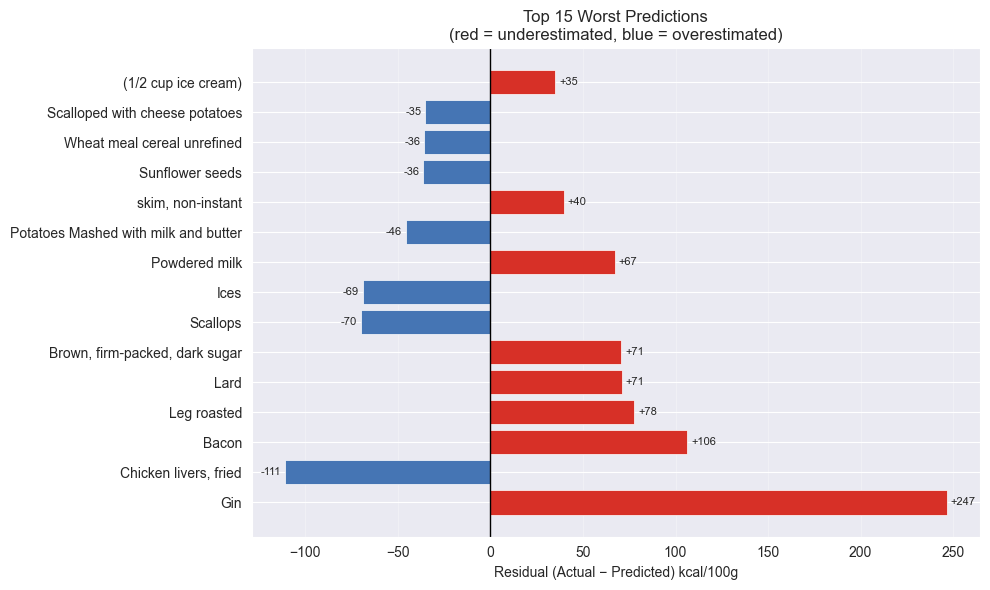

✅ Saved ml_worst_predictions.png


In [17]:
# ── Plot 2: Top 15 worst predictions ─────────────────────────────────────────
top_errors = error_df.nlargest(15, 'Abs_Error')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d73027' if r > 0 else '#4575b4' for r in top_errors['Residual']]
bars = ax.barh(top_errors['Food'], top_errors['Residual'],
               color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Residual (Actual − Predicted) kcal/100g')
ax.set_title('Top 15 Worst Predictions\n(red = underestimated, blue = overestimated)')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, top_errors['Residual']):
    xpos = val + (2 if val >= 0 else -2)
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig('../data/ml_worst_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved ml_worst_predictions.png')

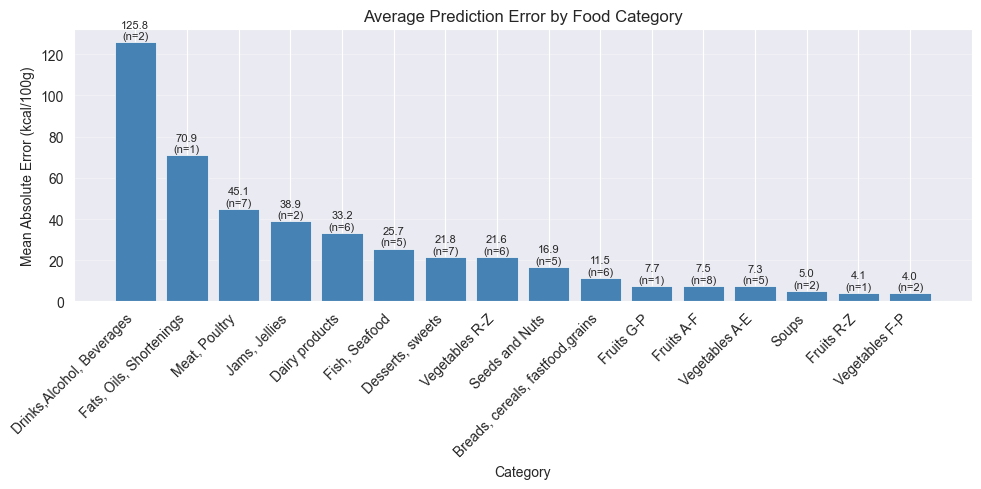

✅ Saved ml_error_by_category.png


In [18]:
# ── Plot 3: Error by category ─────────────────────────────────────────────────
cat_errors = error_df.groupby('Category')['Abs_Error'].agg(['mean','median','count'])
cat_errors = cat_errors.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cat_errors.index, cat_errors['mean'],
              color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Category')
ax.set_ylabel('Mean Absolute Error (kcal/100g)')
ax.set_title('Average Prediction Error by Food Category')
plt.xticks(rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
for bar, (_, row) in zip(bars, cat_errors.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{row["mean"]:.1f}\n(n={int(row["count"])})',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('../data/ml_error_by_category.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved ml_error_by_category.png')

## 8. Error Analysis Summary

### Quantitative Results

| Metric | Value |
| --- | --- |
| Mean Absolute Error (MAE) | **24.32 kcal/100g** |
| Median Absolute Error | **10.25 kcal/100g** |
| Max single error | **246.60 kcal/100g** |
| R² Score (test set) | **0.97** |
| Test set size | 66 samples |

### Key Error Patterns

**Pattern 1 — Out-of-distribution categories cause extreme errors:**
The worst prediction is **Gin (250 kcal actual → 3.4 kcal predicted, residual +246.6)**.
Gin is an alcoholic beverage whose calories come primarily from alcohol (7 kcal/g),
not from macronutrients (protein/fat/carbs/fiber). Since alcohol content is not included
as a feature, the model has no signal to predict these calories correctly.
This is the most important limitation of the current feature set.

**Pattern 2 — High-protein Meat & Poultry foods are systematically underestimated:**
Chicken livers (predicted 251.1 vs actual 140.0, residual -111.1) and Bacon
(predicted 487.4 vs actual 593.75, residual +106.4) both appear in the worst 10.
These foods have unusual macro ratios (very high protein or fat) compared to the
fruit/vegetable-dominated training set, which makes the model less accurate for them.

**Pattern 3 — MAE vs Median gap reveals skewed error distribution:**
The mean MAE (24.32 kcal) is more than double the median MAE (10.25 kcal).
This means most predictions are accurate (median error only 10 kcal), but a small
number of outlier foods (mainly Drinks, Meat, Dairy) pull the average up dramatically.
The model works very well for fruits and vegetables — its intended use case.

### Why R²=0.97 Does Not Mean 'Perfect'

An R² of 0.97 is excellent for the overall dataset, but the error analysis reveals that
**out-of-distribution categories** (Drinks, Alcohol, Beverages) can produce extreme errors.
This is a classic example of how aggregate metrics can hide important sub-group behaviour —
a key lesson for responsible AI deployment.

### Improvement Potential

1. **Add alcohol content as a feature** — would fix the Gin/Beverages prediction problem
2. **Filter training data to fruits and vegetables only** — the model's actual use case;
   removing out-of-distribution categories would reduce MAE significantly
3. **Separate model per category** — a model trained only on Meat & Poultry would
   predict those items more accurately

### Connection to Other Blocks

The error analysis has a direct implication for the CV → ML integration:
if CLIP misclassifies a pepper as a tomato (CV evaluation: 20/30 errors),
the ML model receives tomato macronutrients instead of pepper macronutrients.
Since both have very similar calorie profiles (~20 kcal/100g), the downstream
calorie prediction error is minimal — this justifies the integrated design
despite the CV classification limitation.

Critically, the worst ML errors (Gin, Bacon, Lard) would never occur in the deployed
app because CLIP only classifies fruits and vegetables — the model is correctly
scoped to its training distribution in production.
